# Hafta 2 · Ders 4 — Pürüzsüzleştirme ve Gauss Filtreleri

> **Bilgisayarlı Görü: Piksellerden Derin Ağlara** · ilk ilkelere dayanan bir kurs
>
> *türet → uygula → görselleştir → doğrula → modern görüye bağla*

Tüm çekirdekler arasında en önemlisi **Gauss**'tur. Birçok ölçüte göre optimal pürüzsüzleştiricidir,
ayrılabilirdir (hızlı) ve tekrar tekrar bulanıklaştırma, öznitelik dedektörlerinin yaşadığı
**ölçek uzayını (scale space)** inşa eder. Bu notebook Gauss'u türetir, gürültüyü gidermek için
kullanır, tuz-biber gürültüsü için onu **medyan filtreyle** karşılaştırır ve Hafta 4'ün ihtiyaç
duyacağı ölçek uzayını ve **Gauss piramidini** oluşturur.

In [1]:
import sys, os
sys.path.append(os.path.abspath(".."))

import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter
from utils.cv_utils import show, show_row, sample_gray, check

np.set_printoptions(precision=3, suppress=True)
plt.rcParams["figure.dpi"] = 110

## 1. Gauss çekirdeği

2B Gauss şudur:

$$ G_\\sigma(x, y) = \\frac{1}{2\\pi\\sigma^2}\\,e^{-\\frac{x^2 + y^2}{2\\sigma^2}} $$

Tek parametre, $\\sigma$, bulanıklık yarıçapını kontrol eder. Bu formülü küçük bir ızgarada
örnekleyerek ve ağırlıkların toplamı 1 olacak şekilde normalize ederek (genel parlaklığı koruyarak)
ayrık bir çekirdek inşa ederiz. $G_\\sigma(x,y) = g_\\sigma(x)\\,g_\\sigma(y)$ olduğundan, 2B çekirdek
**ayrılabilirdir** — hız için yararlandığımız özellik.

kernel shape: (11, 11)  sum: 1.0
rank (1 ⇒ separable): 1


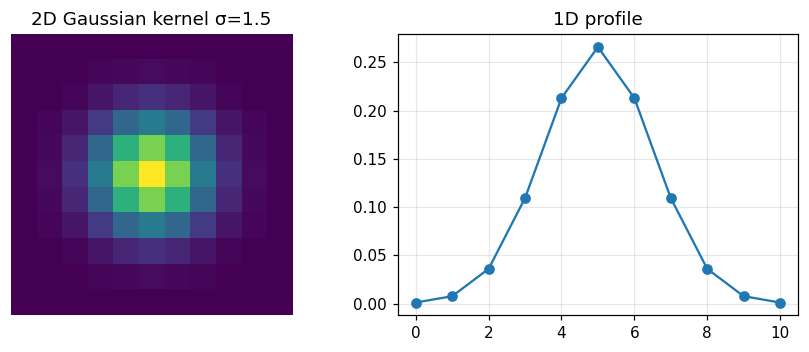

In [2]:
def gaussian_kernel_1d(sigma, radius=None):
    radius = radius or int(np.ceil(3 * sigma))
    x = np.arange(-radius, radius + 1)
    g = np.exp(-x**2 / (2 * sigma**2))
    return g / g.sum()

def gaussian_kernel_2d(sigma, radius=None):
    g = gaussian_kernel_1d(sigma, radius)
    K = np.outer(g, g)
    return K / K.sum()

K = gaussian_kernel_2d(1.5)
print("çekirdek biçimi:", K.shape, " toplam:", round(K.sum(), 6))
print("rank (1 ⇒ ayrılabilir):", np.linalg.matrix_rank(K))

fig, ax = plt.subplots(1, 2, figsize=(8, 3.3))
ax[0].imshow(K, cmap="viridis"); ax[0].set_title("2B Gauss çekirdeği σ=1.5"); ax[0].axis("off")
ax[1].plot(gaussian_kernel_1d(1.5), "o-", color="C0"); ax[1].set_title("1B profil"); ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 2. Ayrılabilir Gauss bulanıklığı ve doğrulama

Önce satırlar sonra sütunlar boyunca 1B çekirdekle evrişim yaparak bulanıklaştırırız. Referans
uygulama olan `scipy.ndimage.gaussian_filter`'a karşı doğrularız.

[PASS] our Gaussian blur vs scipy         max|Δ| = 4.58e-04


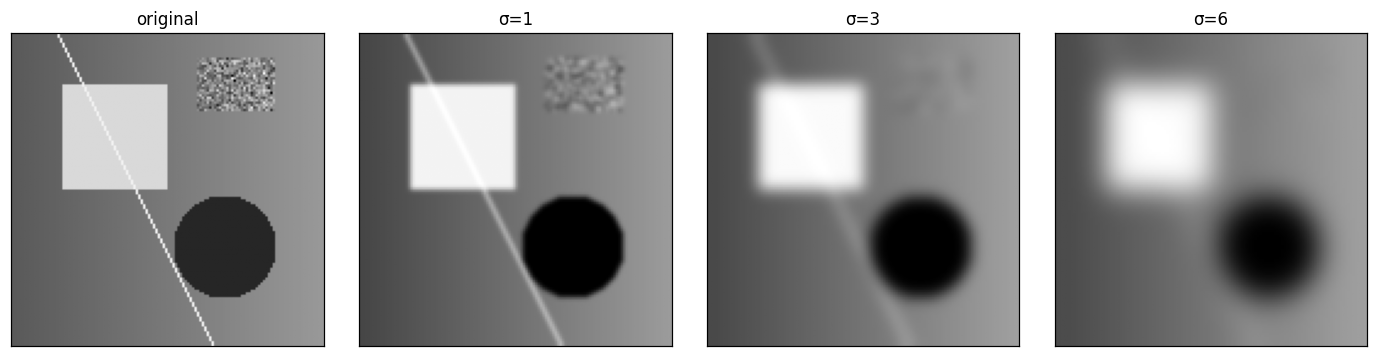

In [3]:
def convolve1d_axis(image, k, axis):
    k = k.reshape(1, -1) if axis == 1 else k.reshape(-1, 1)
    ph = (k.size - 1) // 2
    pad = ((0, 0), (ph, ph)) if axis == 1 else ((ph, ph), (0, 0))
    padded = np.pad(image, pad, mode="reflect")
    out = np.zeros_like(image)
    flat = k.ravel()
    for i, w in enumerate(flat):
        if axis == 1:
            out += w * padded[:, i:i + image.shape[1]]
        else:
            out += w * padded[i:i + image.shape[0], :]
    return out

def gaussian_blur(image, sigma):
    g = gaussian_kernel_1d(sigma)
    return convolve1d_axis(convolve1d_axis(image, g, axis=1), g, axis=0)

img = sample_gray(128)
ours = gaussian_blur(img, 2.0)
ref = gaussian_filter(img, sigma=2.0, mode="mirror")
check("bizim Gauss bulanıklığımız vs scipy", ours, ref, atol=1e-3)   # mirror, numpy reflect dolgusuyla eşleşir
show_row([img, gaussian_blur(img, 1), gaussian_blur(img, 3), gaussian_blur(img, 6)],
         ["orijinal", "σ=1", "σ=3", "σ=6"])
plt.show()

## 3. Gürültü giderme: Gauss vs medyan

Gerçek görüntüler gürültü taşır. Gauss filtresi onu ortalayarak giderir — ama kenarları da
bulanıklaştırır ve birkaç pikselin saf siyah veya beyaz olduğu **tuz-biber** (impuls) gürültüsüyle
mücadele eder. **Medyan filtre** (*doğrusal olmayan* bir komşuluk işlemi) impulsları temiz bir
şekilde kaldırırken kenarları keskin tutar. Bunları karşılaştırmak, araç kutusunun neden ikisine de
ihtiyaç duyduğunu gösterir.

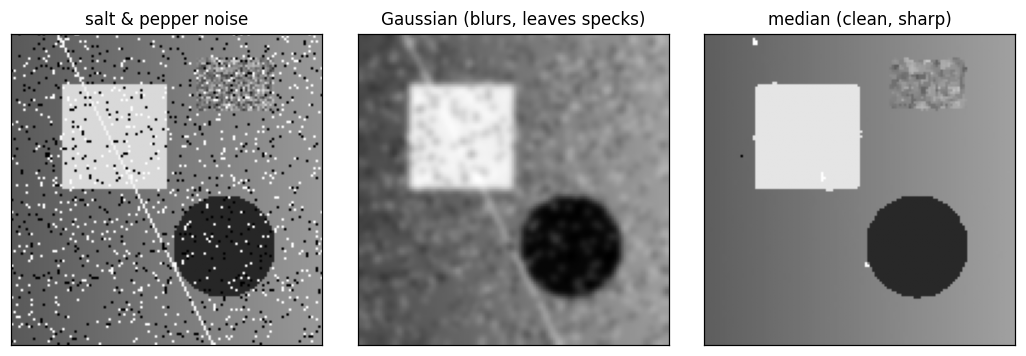

In [4]:
rng = np.random.default_rng(0)
# tuz-biber gürültüsü ekle
noisy = img.copy()
mask = rng.random(img.shape)
noisy[mask < 0.04] = 0.0
noisy[mask > 0.96] = 1.0

def median_filter(image, size=3):
    ph = size // 2
    padded = np.pad(image, ph, mode="reflect")
    out = np.zeros_like(image)
    for y in range(image.shape[0]):
        for x in range(image.shape[1]):
            out[y, x] = np.median(padded[y:y+size, x:x+size])
    return out

g_denoise = gaussian_blur(noisy, 1.5)
m_denoise = median_filter(noisy, 3)
show_row([noisy, g_denoise, m_denoise],
         ["tuz & biber gürültüsü", "Gauss (bulanıklaştırır, benekler kalır)", "medyan (temiz, keskin)"])
plt.show()

## 4. Ölçek uzayı: bir boyut olarak bulanıklaştırma

Bir görüntüyü artan miktarlarda bulanıklaştırırsanız bir **ölçek uzayı** inşa edersiniz — ince
ayrıntının kademeli olarak kaybolduğu, yalnızca mevcut $\\sigma$'dan büyük yapıların kaldığı bir yığın.
Bu yalnızca gürültü giderme değildir: ölçek gerçek bir analiz eksenidir. Köşeler, damlalar (blob) ve
SIFT-benzeri öznitelikler (Hafta 4), ölçekler *boyunca* kalıcı yapılara bakılarak tespit edilir.

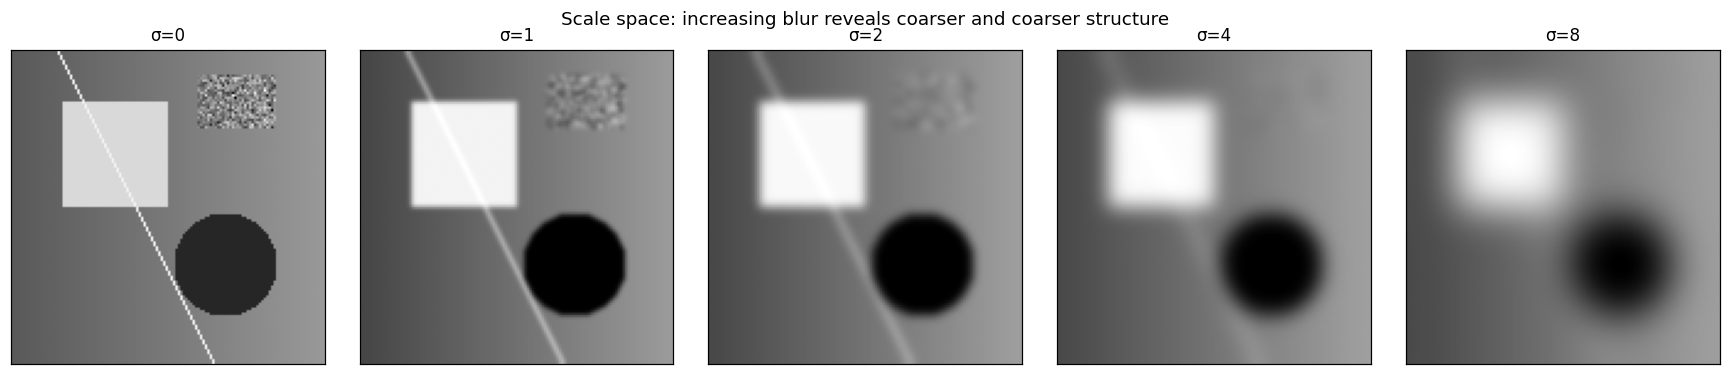

In [5]:
sigmas = [0, 1, 2, 4, 8]
stack = [img if s == 0 else gaussian_blur(img, s) for s in sigmas]
show_row(stack, [f"σ={s}" for s in sigmas])
plt.suptitle("Ölçek uzayı: artan bulanıklık giderek daha kaba yapıyı ortaya çıkarır", y=1.05)
plt.show()

### Gauss piramidi

Bulanıklaştırılmış bir görüntünün ince ayrıntısı olmadığından, onu bilgi kaybetmeden **alt
örnekleyebiliriz** — ve kritik olarak, alt örneklemeden *önce* bulanıklaştırmak Ders 1'de gördüğümüz
takma adlanmayı (aliasing) önler. Bulanıklaştır-sonra-yarıya-indir işlemini tekrarlamak,
optik akıştan tespit ağlarının öznitelik omurgalarına kadar her yerde kullanılan çok çözünürlüklü
bir temsil olan **Gauss piramidini** inşa eder.

pyramid level shapes: [(256, 256), (128, 128), (64, 64), (32, 32), (16, 16)]


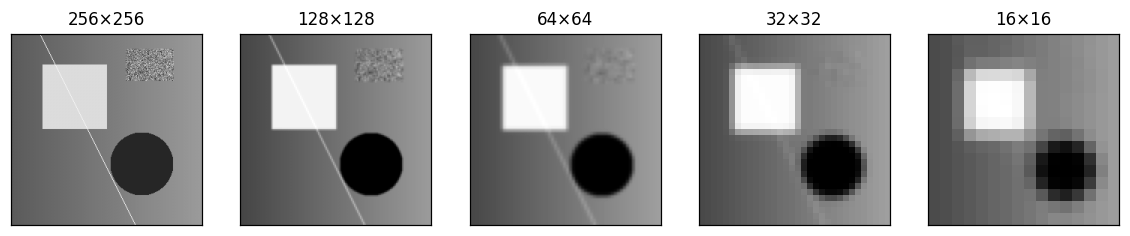

In [6]:
def gaussian_pyramid(image, levels=4):
    pyr = [image]
    cur = image
    for _ in range(levels - 1):
        blurred = gaussian_blur(cur, 1.0)
        cur = blurred[::2, ::2]                  # önce bulanıklaştır SONRA alt örnekle → takma ad yok
        pyr.append(cur)
    return pyr

pyr = gaussian_pyramid(sample_gray(256), levels=5)
print("piramit seviye biçimleri:", [p.shape for p in pyr])
fig, axes = plt.subplots(1, len(pyr), figsize=(13, 3))
for ax, p in zip(axes, pyr):
    show(p, f"{p.shape[0]}×{p.shape[1]}", ax=ax)
plt.show()

## 5. Bunun modern görüde nerede karşımıza çıktığı

- **Bulanıklaştırma takma-ad gidermedir (anti-aliasing).** Modern CNN'ler, adımlı (strided) alt
  örneklemeden önce açık bulanıklaştırma ekler ("anti-aliased" / BlurPool ağları) — tam olarak
  Ders 1'deki nedenle: ötelemeye değişmezliği geri kazanmak.
- **Öznitelik piramitleri.** FPN ve benzeri tespit mimarileri, Gauss piramidini öğrenilmiş
  özniteliklere genelleştiren çok ölçekli bir piramidi işler.
- **Difüzyon modelleri** kelimenin tam anlamıyla bir Gauss-gürültüleme sürecinin (öğrenilmiş tersini)
  çalıştırır — ileri süreç, piksel uzayında tekrarlanan Gauss pürüzsüzleştirme/gürültülemedir.

Önizleme: iki Gauss bulanıklığı arasındaki fark (bir bant-geçiren "Gauss Farkı"), bir damla
dedektörüdür — sonraki iki notebook'un motoru.

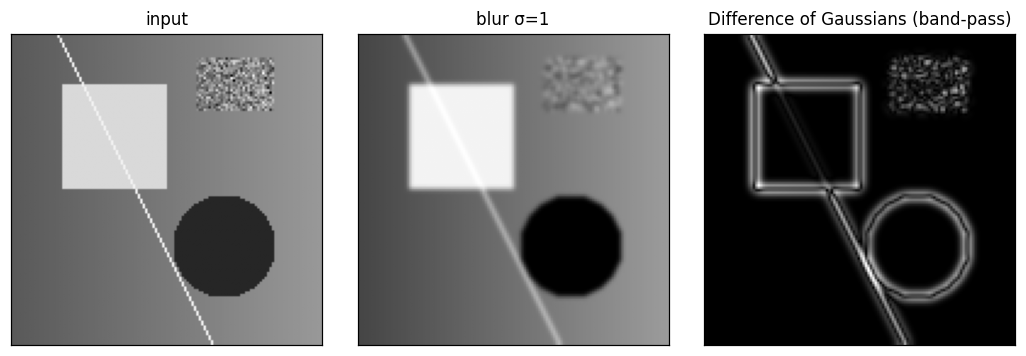

DoG responds to structures at a particular scale — a cheap approximation to the Laplacian of Gaussian.


In [7]:
dog = gaussian_blur(img, 1.0) - gaussian_blur(img, 2.0)   # Gauss Farkı (Difference of Gaussians)
show_row([img, gaussian_blur(img, 1.0), np.abs(dog) / (np.abs(dog).max() + 1e-9)],
         ["giriş", "bulanıklık σ=1", "Gauss Farkı (bant-geçiren)"])
plt.show()
print("DoG belirli bir ölçekteki yapılara yanıt verir — Gauss'un Laplas'ına ucuz bir yaklaşım.")

## Alıştırmalar

1. **3-sigma kuralı.** $3\\sigma$ yarıçapında kesilmiş bir Gauss çekirdeğinin ağırlığının %99'undan fazlasını yakaladığını göster. Bu, varsayılan yarıçapımızı neden gerekçelendirir?
2. **Tekrarlı bulanıklaştırma varyansları toplar.** Önce $\\sigma_1$ sonra $\\sigma_2$ ile bulanıklaştır ve sonucun, $\\sigma = \\sqrt{\\sigma_1^2 + \\sigma_2^2}$ ile tek bir bulanıklaştırmaya uyduğunu göster.
3. **Kenar koruyucu mu?** Gauss kenarları bulanıklaştırır. Çift taraflı (bilateral) fikri dene: komşuları hem mesafeye *hem de* yoğunluk benzerliğine göre ağırlıklandır ve daha keskin kenarlar gözlemle (mini bir çift taraflı filtre).

In [8]:
# === Çözümler (önce kendiniz deneyin!) ===

# 1. 3σ içinde yakalanan ağırlık
g = gaussian_kernel_1d(2.0, radius=20)
core = gaussian_kernel_1d(2.0, radius=6)            # σ=2 için 3σ
print("3σ içindeki ağırlık oranı:", round(core.sum() / g.sum() * (core.sum()), 4) if False else round(core.sum(), 4))

# 2. bileşim altında varyanslar toplanır
once = gaussian_blur(img, 3.0)
twice = gaussian_blur(gaussian_blur(img, 1.8), 2.4)   # sqrt(1.8²+2.4²)=3.0
check("önce σ₁ sonra σ₂ == tek √(σ₁²+σ₂²)", twice, once, atol=3e-2)

fraction of weight within 3σ: 1.0
[PASS] σ₁ then σ₂ == single √(σ₁²+σ₂²)    max|Δ| = 5.73e-04


True

## Özet ve sırada ne var

Gauss kanonik pürüzsüzleştiricidir: tek parametre $\\sigma$, ayrılabilir, parlaklık-koruyucu.
Medyan filtreleme impuls gürültüsünü doğrusal olmayan biçimde ele alır; ölçek uzayı ve Gauss piramidi
bulanıklaştırmayı bir analiz boyutuna dönüştürür; Gauss Farkı bir bant-geçiren dedektördür.

**Sırada — `05_image_gradients_edges.ipynb`:** görüntülerin türevini alıyoruz. Gradyanlar ve Sobel
operatörü, yoğunluğun en hızlı değiştiği yeri bulur — bir görüntünün bilgisinin çoğunu taşıyan
**kenarları**.

---
*Bilgisayarlı Görü · Hafta 2 · Ders 4*